# SPAM2020：全作物の作付面積割合と優占作物

このノートブックは、SPAM2020 V2r2 の全46作物・作物群について、5 arc-minutes（GAEZと同じ解像度）のphysical areaを読み込み、次を作成する。

1. 各グリッドの全作物physical area合計
2. 各作物の作付面積割合
3. 各グリッドの優占作物（physical areaが最大の作物）
4. 優占作物の地図

作付面積割合は2種類保存する。

- share_of_spam_crops：SPAMに含まれる46作物の合計に占める割合。作物構成の比較用。
- share_of_cropland：2020年のHYDE cropland areaに占める割合。第2段階の分解式 A_i L_i s_ic に対応する割合。46作物以外・休耕地は残差として残る。

SPAMのファイル名に含まれる最後のコードは、I=irrigated、R=rainfed、A=all systemsを表す。ここでは作物選択の基本目的変数として、_A_<CROP>_A.tifを使う。


In [1]:
from pathlib import Path
import gc
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from matplotlib.colors import BoundaryNorm, ListedColormap, Normalize
from numpy.lib.format import open_memmap

# ------------------------------------------------------------------
# サーバー上のパス
# ------------------------------------------------------------------
ROOT = Path("/work/tsuda")
GAEZ_DIR = ROOT / "GAEZ"
SPAM_ROOT = GAEZ_DIR / "SPAM2020"
CROPLAND_DIR = ROOT / "HYDE" / "cropland_npys"
OUTPUT_DIR = SPAM_ROOT / "visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# SPAM2020のファイルはSPAM_ROOT以下の深い階層に展開されていてもよい
print("SPAM_ROOT:", SPAM_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("CROPLAND_DIR:", CROPLAND_DIR)


SPAM_ROOT: /work/tsuda/GAEZ/SPAM2020
OUTPUT_DIR: /work/tsuda/GAEZ/SPAM2020/visualization
CROPLAND_DIR: /work/tsuda/HYDE/cropland_npys


In [2]:
# SPAM2020 GeoTIFFを発見し、作物コードと生産システムを整理する

FILENAME_RE = re.compile(
    r"_A_(?P<crop>[A-Z0-9]+)_(?P<system>[AIR])$",
    re.IGNORECASE,
)

tif_paths = sorted(
    p for p in SPAM_ROOT.rglob("*")
    if p.is_file() and p.suffix.lower() in {".tif", ".tiff"}
)

if not tif_paths:
    raise FileNotFoundError(f"GeoTIFFが見つかりません: {SPAM_ROOT}")

def parse_spam_filename(path):
    match = FILENAME_RE.search(path.stem)
    if match is None:
        return None
    return match.group("crop").upper(), match.group("system").upper()

system_rasters = {}
for path in tif_paths:
    parsed = parse_spam_filename(path)
    if parsed is None:
        continue
    crop_code, system_code = parsed
    system_rasters.setdefault(crop_code, {})[system_code] = path

crop_codes = sorted(
    crop_code for crop_code, files in system_rasters.items()
    if "A" in files
)
total_rasters = {crop_code: system_rasters[crop_code]["A"] for crop_code in crop_codes}

print(f"発見したGeoTIFF数: {len(tif_paths)}")
print(f"作物・作物群数: {len(crop_codes)}")
print(f"生産システムコード: {sorted({s for files in system_rasters.values() for s in files})}")
print("想定: 46作物群 × 3システム = 138ファイル")
print("作物コード:", crop_codes)

missing_systems = {
    crop_code: sorted({"I", "R", "A"} - set(system_rasters[crop_code]))
    for crop_code in crop_codes
    if set(system_rasters[crop_code]) != {"I", "R", "A"}
}
if missing_systems:
    print("不足している生産システム:", missing_systems)

pd.DataFrame(
    [
        {
            "crop_code": crop_code,
            "irrigated": str(system_rasters[crop_code].get("I", "")),
            "rainfed": str(system_rasters[crop_code].get("R", "")),
            "all_systems": str(system_rasters[crop_code].get("A", "")),
        }
        for crop_code in crop_codes
    ]
).head()


発見したGeoTIFF数: 138
作物・作物群数: 46
生産システムコード: ['A', 'I', 'R']
想定: 46作物群 × 3システム = 138ファイル
作物コード: ['BANA', 'BARL', 'BEAN', 'CASS', 'CHIC', 'CITR', 'CNUT', 'COCO', 'COFF', 'COTT', 'COWP', 'GROU', 'LENT', 'MAIZ', 'MILL', 'OCER', 'OFIB', 'OILP', 'ONIO', 'OOIL', 'OPUL', 'ORTS', 'PIGE', 'PLNT', 'PMIL', 'POTA', 'RAPE', 'RCOF', 'REST', 'RICE', 'RUBB', 'SESA', 'SORG', 'SOYB', 'SUGB', 'SUGC', 'SUNF', 'SWPO', 'TEAS', 'TEMF', 'TOBA', 'TOMA', 'TROF', 'VEGE', 'WHEA', 'YAMS']


,crop_code,irrigated,rainfed,all_systems
0,BANA,/work/tsuda/GAEZ/SPAM2020/spam2020V2r2_global_...,/work/tsuda/GAEZ/SPAM2020/spam2020V2r2_global_...,/work/tsuda/GAEZ/SPAM2020/spam2020V2r2_global_...
1,BARL,/work/tsuda/GAEZ/SPAM2020/spam2020V2r2_global_...,/work/tsuda/GAEZ/SPAM2020/spam2020V2r2_global_...,/work/tsuda/GAEZ/SPAM2020/spam2020V2r2_global_...
2,BEAN,/work/tsuda/GAEZ/SPAM2020/spam2020V2r2_global_...,/work/tsuda/GAEZ/SPAM2020/spam2020V2r2_global_...,/work/tsuda/GAEZ/SPAM2020/spam2020V2r2_global_...
3,CASS,/work/tsuda/GAEZ/SPAM2020/spam2020V2r2_global_...,/work/tsuda/GAEZ/SPAM2020/spam2020V2r2_global_...,/work/tsuda/GAEZ/SPAM2020/spam2020V2r2_global_...
4,CHIC,/work/tsuda/GAEZ/SPAM2020/spam2020V2r2_global_...,/work/tsuda/GAEZ/SPAM2020/spam2020V2r2_global_...,/work/tsuda/GAEZ/SPAM2020/spam2020V2r2_global_...


In [3]:
# グリッド情報を確認する

reference_path = total_rasters[crop_codes[0]]

with rasterio.open(reference_path) as src:
    reference_profile = src.profile.copy()
    height, width = src.height, src.width
    reference_transform = src.transform
    reference_crs = src.crs
    reference_bounds = src.bounds
    reference_shape = (height, width)

print("reference raster:", reference_path.name)
print("shape:", reference_shape)
print("crs:", reference_crs)
print("resolution:", reference_transform.a, abs(reference_transform.e))
print("bounds:", reference_bounds)

# 全作物の合計ファイルが同じグリッドか確認
for crop_code, path in total_rasters.items():
    with rasterio.open(path) as src:
        if (src.height, src.width) != reference_shape:
            raise ValueError(f"shape mismatch: {crop_code} {src.shape}")
        if src.crs != reference_crs:
            raise ValueError(f"CRS mismatch: {crop_code} {src.crs}")

print("全作物の合計physical-area rasterは同じグリッドです。")


reference raster: spam2020_V2r2_global_A_BANA_A.tif
shape: (2160, 4320)
crs: EPSG:4326
resolution: 0.0833333333333144 0.0833333333333144
bounds: BoundingBox(left=-180.0, bottom=-89.99999999995906, right=179.9999999999182, top=90.00000000000004)
全作物の合計physical-area rasterは同じグリッドです。


In [4]:
# HYDE 2020 cropland areaを読み込む
# 見つからない場合でも、SPAM内の作物構成シェアは作成する。

def first_existing(paths):
    for path in paths:
        if path.exists():
            return path
    return None

cropland_fraction_path = CROPLAND_DIR / "cropland_fraction_1950_2024.npy"
years_path = CROPLAND_DIR / "years.npy"

grid_area_path = first_existing(
    [
        CROPLAND_DIR / "grid_area_ha.npy",
        CROPLAND_DIR / "grid_area_km2.npy",
        GAEZ_DIR / "grid_area_2160x4320_ha.npy",
    ]
)

cropland_area_ha = None

if cropland_fraction_path.exists() and years_path.exists() and grid_area_path is not None:
    years = np.load(years_path)
    year_index = np.flatnonzero(years == 2020)
    if len(year_index) != 1:
        raise ValueError(f"2020年のHYDE layerが一意に見つかりません: {years}")

    fractions = np.load(cropland_fraction_path, mmap_mode="r")
    fraction_2020 = np.asarray(fractions[int(year_index[0])], dtype=np.float32)

    grid_area = np.asarray(np.load(grid_area_path, mmap_mode="r"), dtype=np.float32)
    if grid_area_path.name == "grid_area_km2.npy":
        grid_area = grid_area * 100.0

    if fraction_2020.shape != reference_shape or grid_area.shape != reference_shape:
        raise ValueError(
            f"HYDE/grid area shape mismatch: "
            f"fraction={fraction_2020.shape}, grid_area={grid_area.shape}, "
            f"SPAM={reference_shape}"
        )

    fraction_2020 = np.nan_to_num(fraction_2020, nan=0.0, posinf=0.0, neginf=0.0)
    fraction_2020 = np.clip(fraction_2020, 0.0, 1.0)
    cropland_area_ha = fraction_2020 * grid_area

    print("HYDE cropland fraction:", cropland_fraction_path)
    print("grid area:", grid_area_path)
    print("cropland area shape:", cropland_area_ha.shape)
else:
    print("HYDE 2020 cropland areaが見つからないため、share_of_croplandは作成しません。")
    print("SPAM46作物内のshare_of_spam_cropsは作成します。")


HYDE 2020 cropland areaが見つからないため、share_of_croplandは作成しません。
SPAM46作物内のshare_of_spam_cropsは作成します。


In [5]:
# 全46作物のphysical areaと作付面積割合を作成
#
# 全作物cubeは約1.7 GB、share cubeも約1.7 GBになるため、
# 標準.npy形式のmemmapとして作成する。

def read_area(path):
    with rasterio.open(path) as src:
        area = src.read(1, masked=True).filled(0).astype(np.float32)
    area[~np.isfinite(area)] = 0.0
    area[area < 0] = 0.0
    return area

n_crops = len(crop_codes)
area_cube_path = OUTPUT_DIR / "spam2020_total_physical_area_all_crops.npy"
share_spam_path = OUTPUT_DIR / "spam2020_share_of_spam_crops_all_crops.npy"
share_cropland_path = OUTPUT_DIR / "spam2020_share_of_cropland_all_crops.npy"
total_area_path = OUTPUT_DIR / "spam2020_total_physical_area_all_crops_ha.npy"

area_cube = open_memmap(
    area_cube_path,
    mode="w+",
    dtype=np.float32,
    shape=(n_crops, height, width),
)
total_area = np.zeros(reference_shape, dtype=np.float32)

for index, crop_code in enumerate(crop_codes):
    area = read_area(total_rasters[crop_code])
    if area.shape != reference_shape:
        raise ValueError(f"{crop_code}: {area.shape} != {reference_shape}")
    area_cube[index] = area
    total_area += area
    print(f"{index + 1:02d}/{n_crops}: {crop_code}")

area_cube.flush()
np.save(total_area_path, total_area)

# SPAMに収録されている作物合計に対するシェア
share_spam = open_memmap(
    share_spam_path,
    mode="w+",
    dtype=np.float32,
    shape=(n_crops, height, width),
)

for index in range(n_crops):
    share_spam[index] = np.divide(
        area_cube[index],
        total_area,
        out=np.zeros_like(total_area, dtype=np.float32),
        where=total_area > 0,
    )

share_spam.flush()

# cropland areaに対するシェア
# これはA_i × L_i × s_icのs_icに対応する。
share_cropland = None
if cropland_area_ha is not None:
    share_cropland = open_memmap(
        share_cropland_path,
        mode="w+",
        dtype=np.float32,
        shape=(n_crops, height, width),
    )
    for index in range(n_crops):
        share_cropland[index] = np.divide(
            area_cube[index],
            cropland_area_ha,
            out=np.zeros_like(cropland_area_ha, dtype=np.float32),
            where=cropland_area_ha > 0,
        )
    share_cropland.flush()

np.save(OUTPUT_DIR / "spam2020_crop_codes.npy", np.asarray(crop_codes))
metadata = {
    "dataset": "SPAM2020 V2r2",
    "reference_year": 2020,
    "resolution": "5 arc-minutes",
    "shape": [int(height), int(width)],
    "crop_count": int(n_crops),
    "crop_codes": crop_codes,
    "area_unit": "ha",
    "area_definition": "physical area",
    "share_spam_definition": "crop physical area / sum of 46 SPAM crop physical areas",
    "share_cropland_definition": "crop physical area / HYDE 2020 cropland area",
}
(OUTPUT_DIR / "spam2020_metadata.json").write_text(
    json.dumps(metadata, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("保存完了:", OUTPUT_DIR)


01/46: BANA
02/46: BARL
03/46: BEAN
04/46: CASS
05/46: CHIC
06/46: CITR
07/46: CNUT
08/46: COCO
09/46: COFF
10/46: COTT
11/46: COWP
12/46: GROU
13/46: LENT
14/46: MAIZ
15/46: MILL
16/46: OCER
17/46: OFIB
18/46: OILP
19/46: ONIO
20/46: OOIL
21/46: OPUL
22/46: ORTS
23/46: PIGE
24/46: PLNT
25/46: PMIL
26/46: POTA
27/46: RAPE
28/46: RCOF
29/46: REST
30/46: RICE
31/46: RUBB
32/46: SESA
33/46: SORG
34/46: SOYB
35/46: SUGB
36/46: SUGC
37/46: SUNF
38/46: SWPO
39/46: TEAS
40/46: TEMF
41/46: TOBA
42/46: TOMA
43/46: TROF
44/46: VEGE
45/46: WHEA
46/46: YAMS
保存完了: /work/tsuda/GAEZ/SPAM2020/visualization


In [6]:
# 各グリッドの優占作物を計算する

dominant_index = np.full(reference_shape, -1, dtype=np.int16)
dominant_area = np.zeros(reference_shape, dtype=np.float32)

for index in range(n_crops):
    area = area_cube[index]
    update = area > dominant_area
    dominant_area[update] = area[update]
    dominant_index[update] = index

dominant_share = np.divide(
    dominant_area,
    total_area,
    out=np.zeros_like(total_area, dtype=np.float32),
    where=total_area > 0,
)

# 作物コードの2次元配列も保存
dominant_code = np.full(reference_shape, "NONE", dtype="<U8")
valid = dominant_index >= 0
code_array = np.asarray(crop_codes)
dominant_code[valid] = code_array[dominant_index[valid]]

np.save(OUTPUT_DIR / "spam2020_dominant_crop_index.npy", dominant_index)
np.save(OUTPUT_DIR / "spam2020_dominant_crop_code.npy", dominant_code)
np.save(OUTPUT_DIR / "spam2020_dominant_crop_share.npy", dominant_share)

# 優占作物の面積・グリッド数集計
summary_rows = []
for index, crop_code in enumerate(crop_codes):
    crop_area_total_ha = float(np.asarray(area_cube[index]).sum(dtype=np.float64))
    n_dominant_cells = int(np.count_nonzero(dominant_index == index))
    summary_rows.append(
        {
            "crop_code": crop_code,
            "total_physical_area_ha": crop_area_total_ha,
            "dominant_grid_cells": n_dominant_cells,
        }
    )

dominant_summary = (
    pd.DataFrame(summary_rows)
    .sort_values("dominant_grid_cells", ascending=False)
    .reset_index(drop=True)
)
dominant_summary["dominant_grid_share"] = (
    dominant_summary["dominant_grid_cells"] / int(np.count_nonzero(valid))
)

dominant_summary.to_csv(
    OUTPUT_DIR / "spam2020_dominant_crop_summary.csv",
    index=False,
)

dominant_summary.head(15)


,crop_code,total_physical_area_ha,dominant_grid_cells,dominant_grid_share
0,WHEA,1.943924e+08,189482,0.196489
1,MAIZ,1.765359e+08,135595,0.140609
2,SOYB,1.194583e+08,84072,0.087181
3,RICE,1.094757e+08,62112,0.064409
4,CASS,2.199720e+07,33890,0.035143
5,BARL,5.014669e+07,32398,0.033596
6,SORG,3.710122e+07,28278,0.029324
7,BEAN,3.010673e+07,27880,0.028911
8,TEMF,2.485821e+07,26368,0.027343
9,OCER,2.481892e+07,24180,0.025074


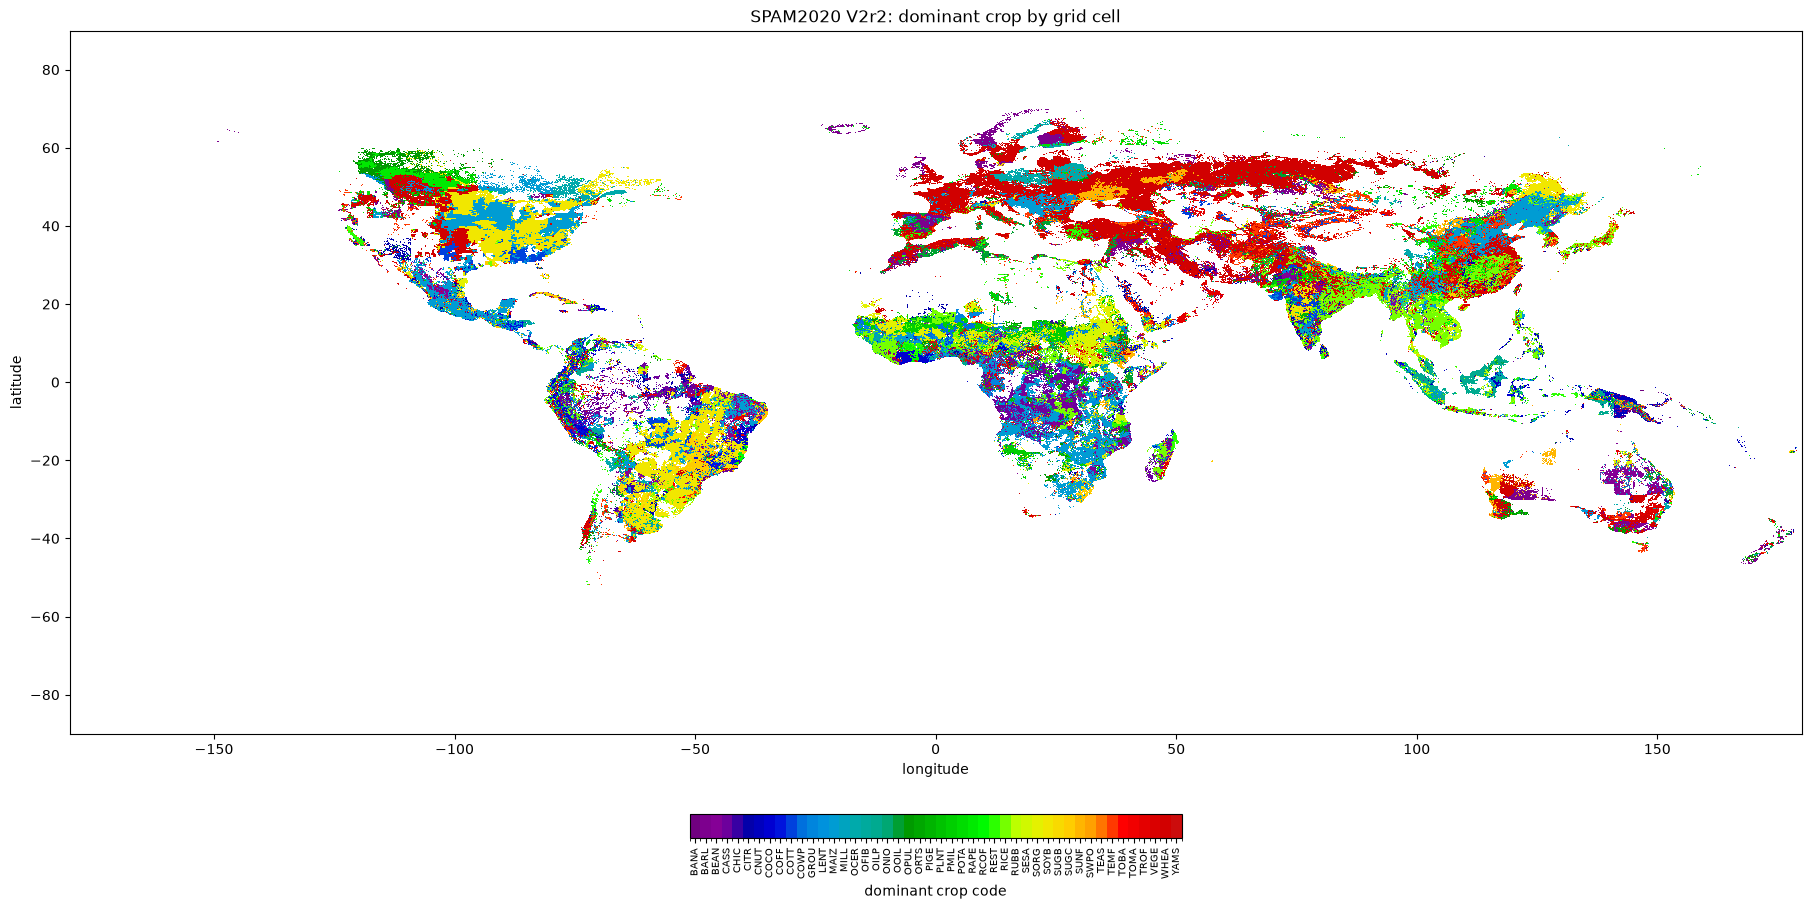

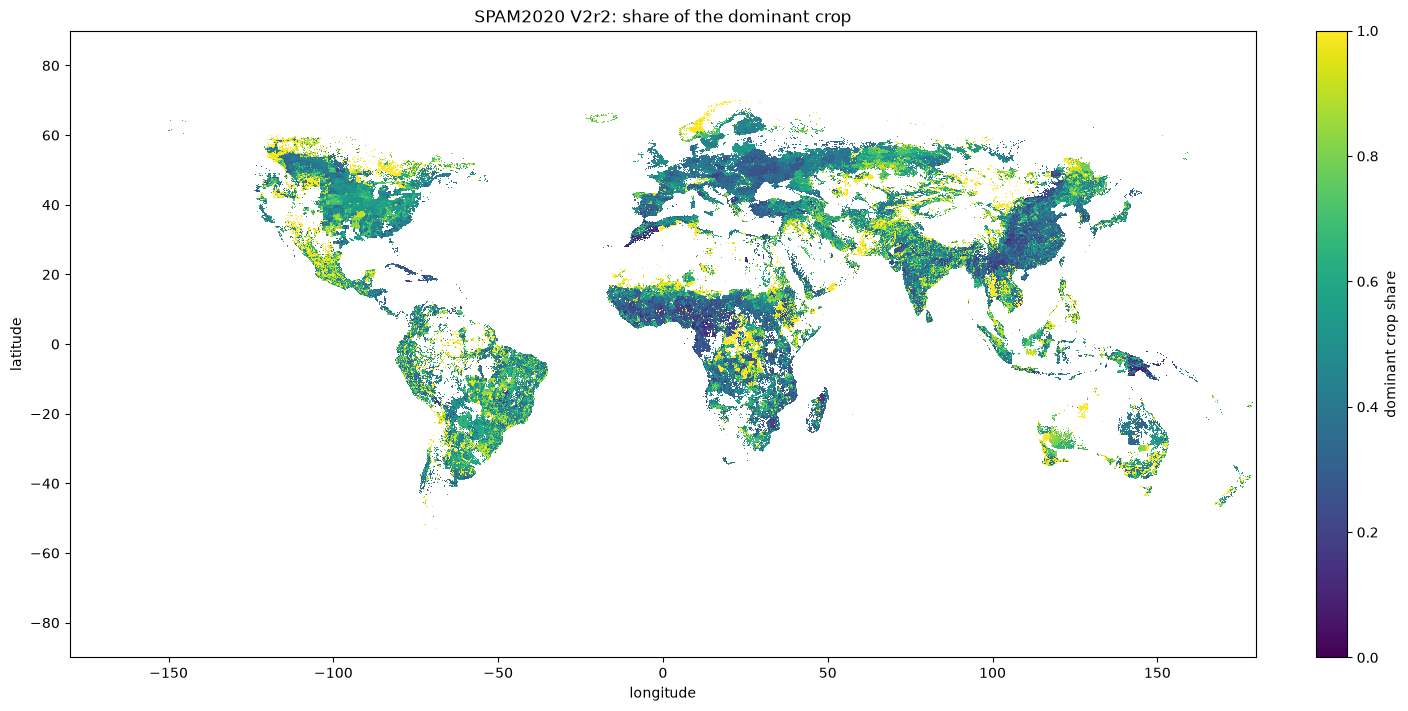

/work/tsuda/GAEZ/SPAM2020/visualization/spam2020_dominant_crop_map.png
/work/tsuda/GAEZ/SPAM2020/visualization/spam2020_dominant_crop_share_map.png


In [7]:
# 優占作物マップを描画する

colors = plt.cm.nipy_spectral(np.linspace(0.05, 0.95, n_crops))
dominant_cmap = ListedColormap(colors)
dominant_norm = BoundaryNorm(
    np.arange(-0.5, n_crops + 0.5, 1),
    n_crops,
)

dominant_for_plot = np.ma.masked_where(dominant_index < 0, dominant_index)

fig, ax = plt.subplots(figsize=(18, 9), constrained_layout=True)
image = ax.imshow(
    dominant_for_plot,
    cmap=dominant_cmap,
    norm=dominant_norm,
    extent=(
        reference_bounds.left,
        reference_bounds.right,
        reference_bounds.bottom,
        reference_bounds.top,
    ),
    interpolation="nearest",
    aspect="auto",
)
ax.set_title("SPAM2020 V2r2: dominant crop by grid cell")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")

colorbar = fig.colorbar(
    image,
    ax=ax,
    orientation="horizontal",
    fraction=0.035,
    pad=0.05,
    ticks=np.arange(n_crops),
)
colorbar.ax.set_xticklabels(crop_codes, rotation=90, fontsize=7)
colorbar.set_label("dominant crop code")

dominant_map_path = OUTPUT_DIR / "spam2020_dominant_crop_map.png"
fig.savefig(dominant_map_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)

# 優占作物のシェア（そのグリッド内のSPAM46作物合計に対する最大シェア）
fig, ax = plt.subplots(figsize=(14, 7), constrained_layout=True)
dominant_share_for_plot = np.ma.masked_where(dominant_index < 0, dominant_share)
image = ax.imshow(
    dominant_share_for_plot,
    cmap="viridis",
    vmin=0,
    vmax=1,
    extent=(
        reference_bounds.left,
        reference_bounds.right,
        reference_bounds.bottom,
        reference_bounds.top,
    ),
    interpolation="nearest",
    aspect="auto",
)
ax.set_title("SPAM2020 V2r2: share of the dominant crop")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
fig.colorbar(image, ax=ax, label="dominant crop share")

dominant_share_map_path = OUTPUT_DIR / "spam2020_dominant_crop_share_map.png"
fig.savefig(dominant_share_map_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)

print(dominant_map_path)
print(dominant_share_map_path)


In [8]:
# 作成したファイル一覧
for path in sorted(OUTPUT_DIR.iterdir()):
    print(f"{path.name:55s} {path.stat().st_size / 1024**2:8.1f} MB")


spam2020_crop_codes.npy                                      0.0 MB
spam2020_dominant_crop_code.npy                            284.8 MB
spam2020_dominant_crop_index.npy                            17.8 MB
spam2020_dominant_crop_map.png                               0.6 MB
spam2020_dominant_crop_share.npy                            35.6 MB
spam2020_dominant_crop_share_map.png                         1.1 MB
spam2020_dominant_crop_summary.csv                           0.0 MB
spam2020_geotiff_inventory.csv                               0.0 MB
spam2020_metadata.json                                       0.0 MB
spam2020_physical_area_maps.png                              0.7 MB
spam2020_share_of_spam_crops_all_crops.npy                1637.4 MB
spam2020_total_physical_area_all_crops.npy                1637.4 MB
spam2020_total_physical_area_all_crops_ha.npy               35.6 MB


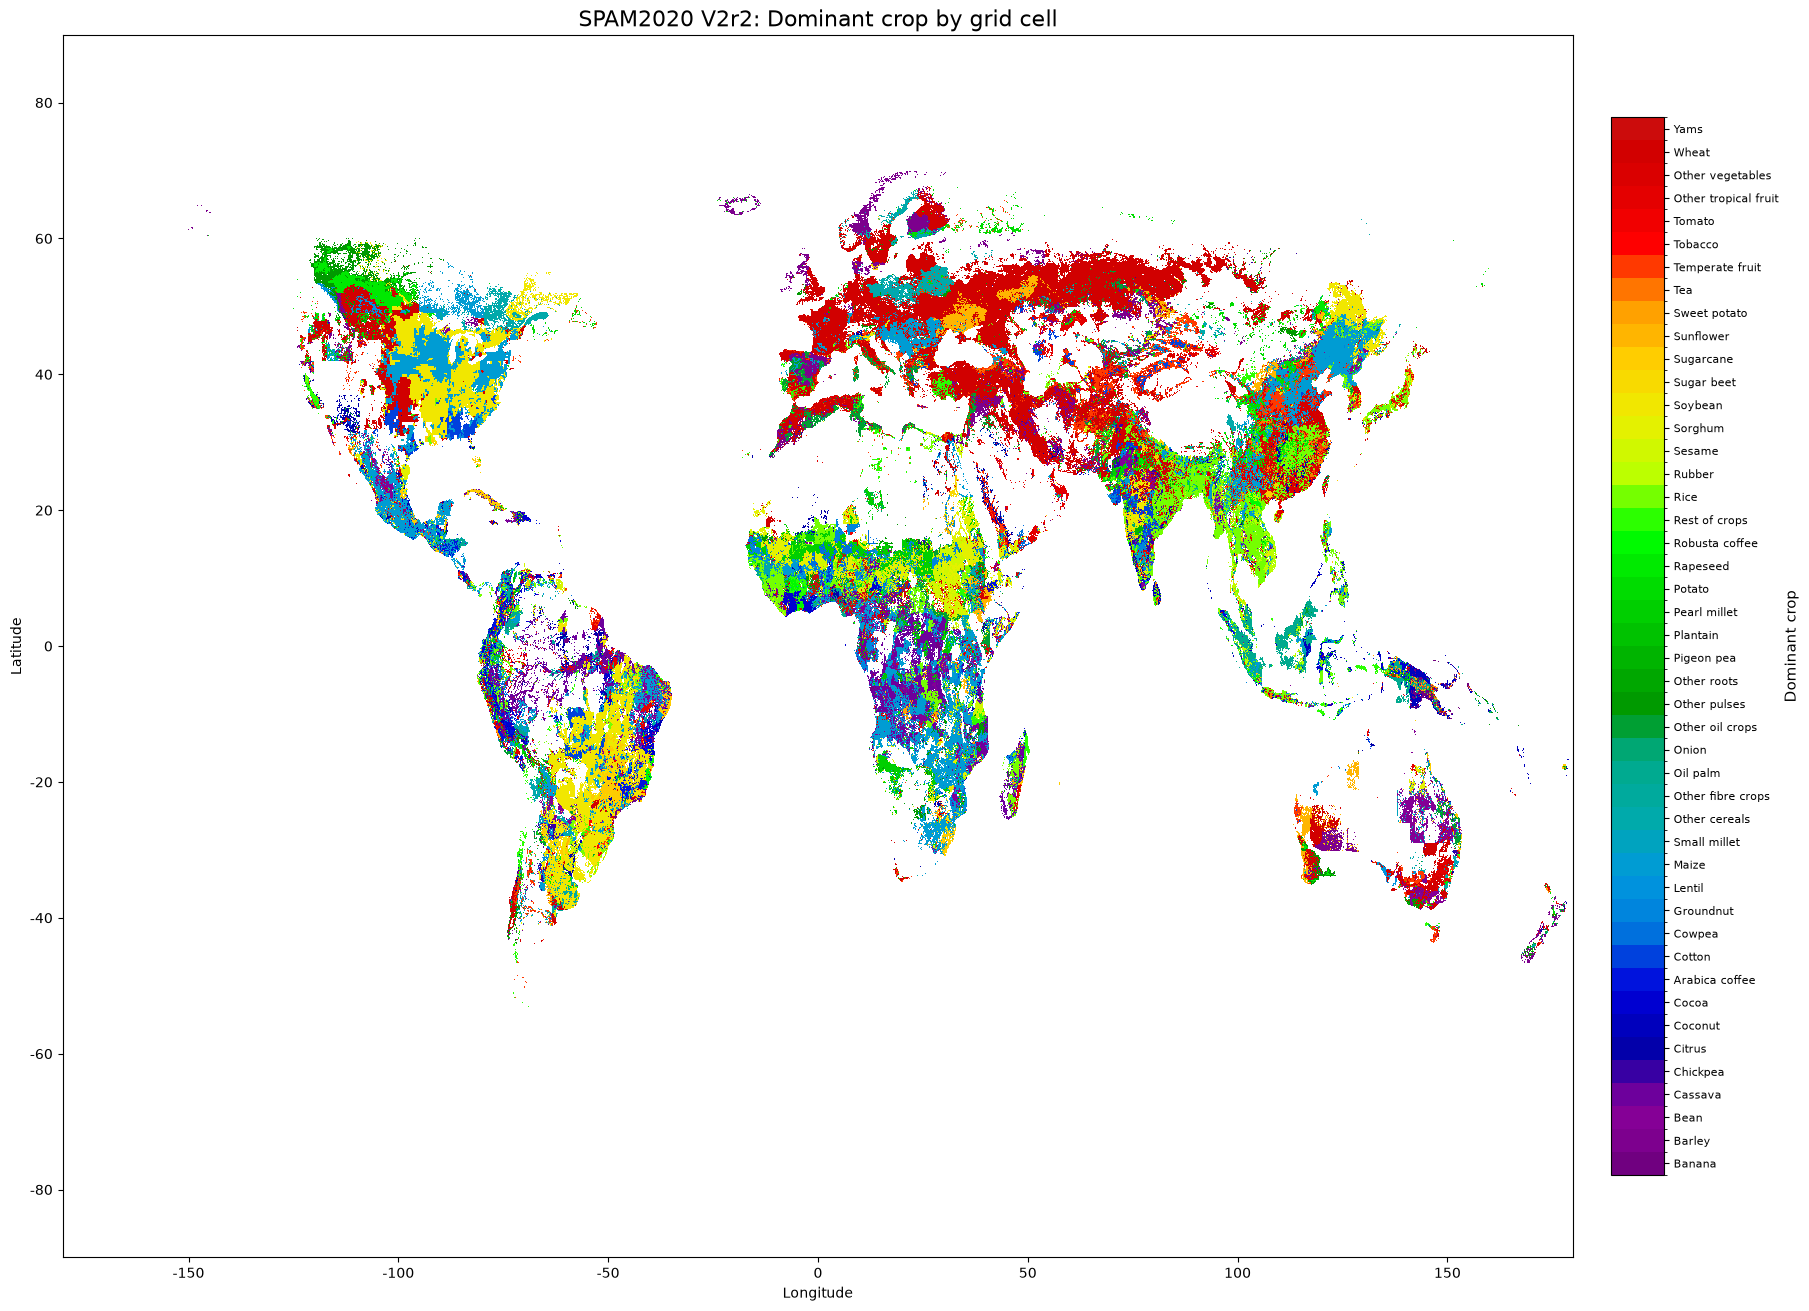

Saved: /work/tsuda/GAEZ/SPAM2020/visualization/spam2020_dominant_crop_map_english_legend.png


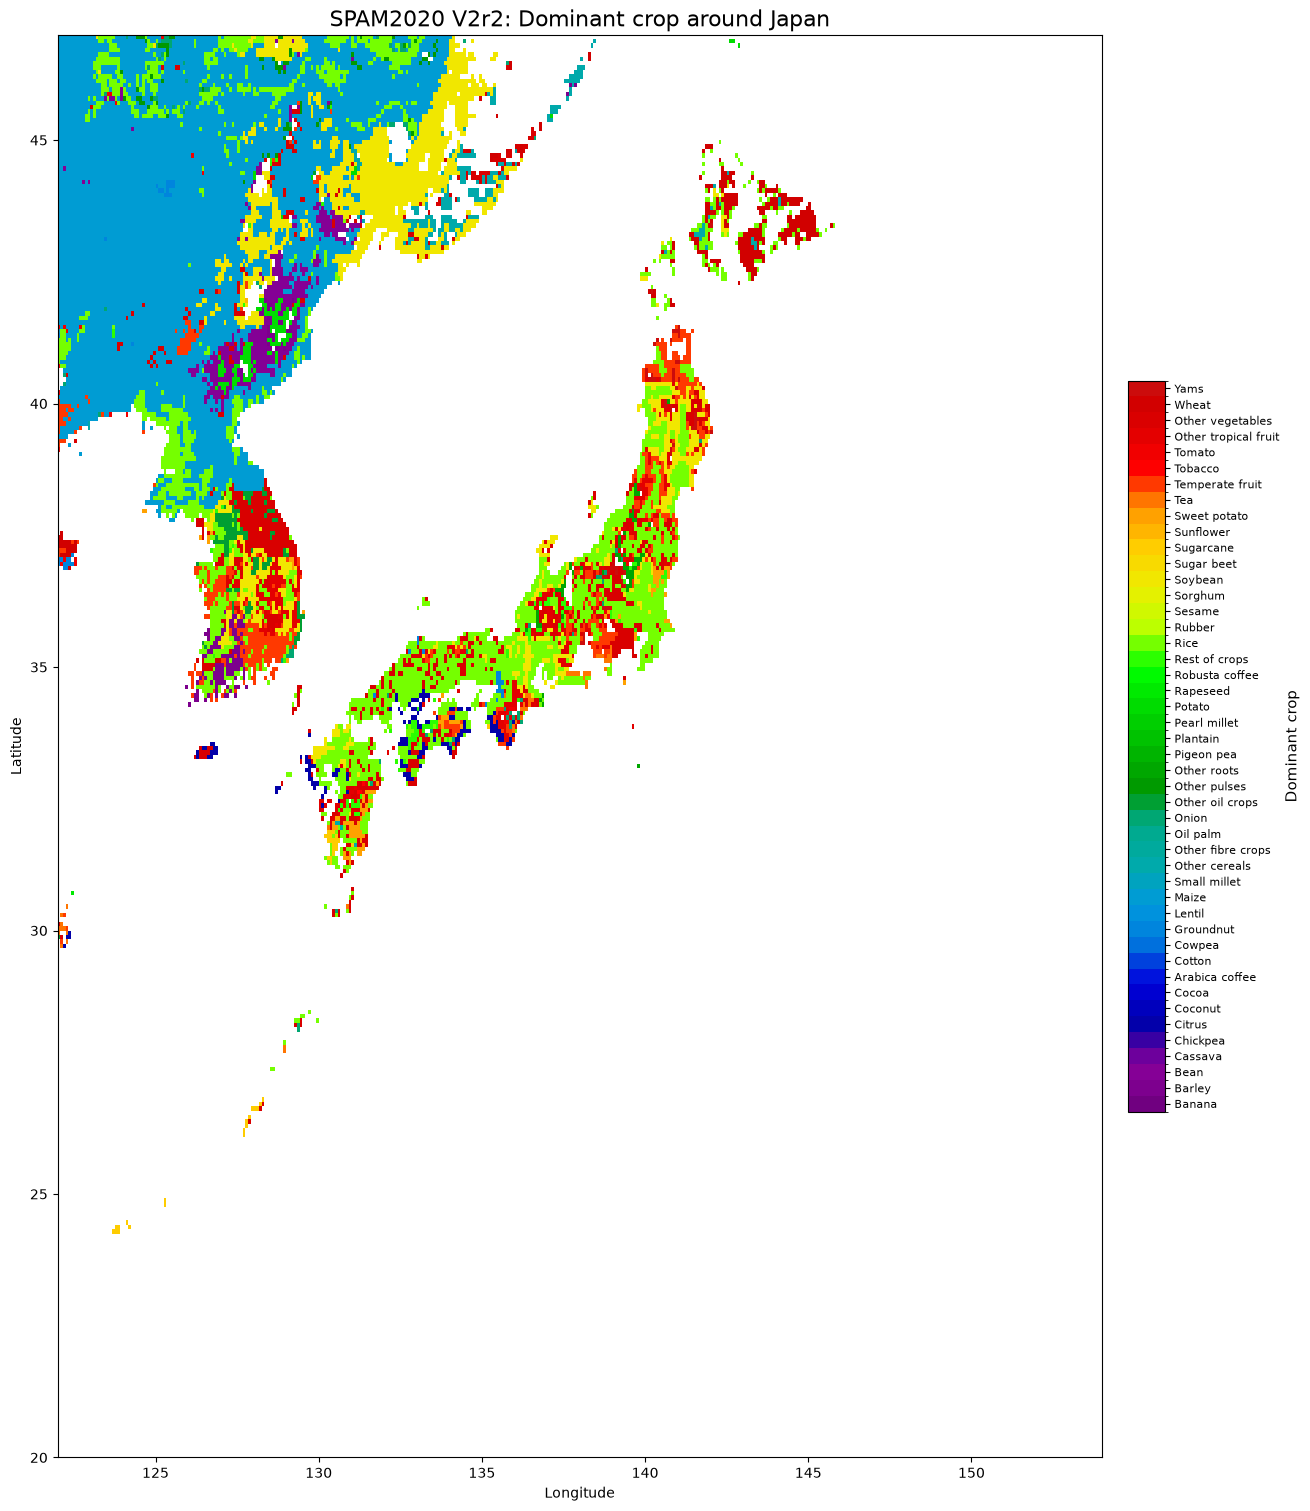

Saved: /work/tsuda/GAEZ/SPAM2020/visualization/spam2020_dominant_crop_map_japan_english.png


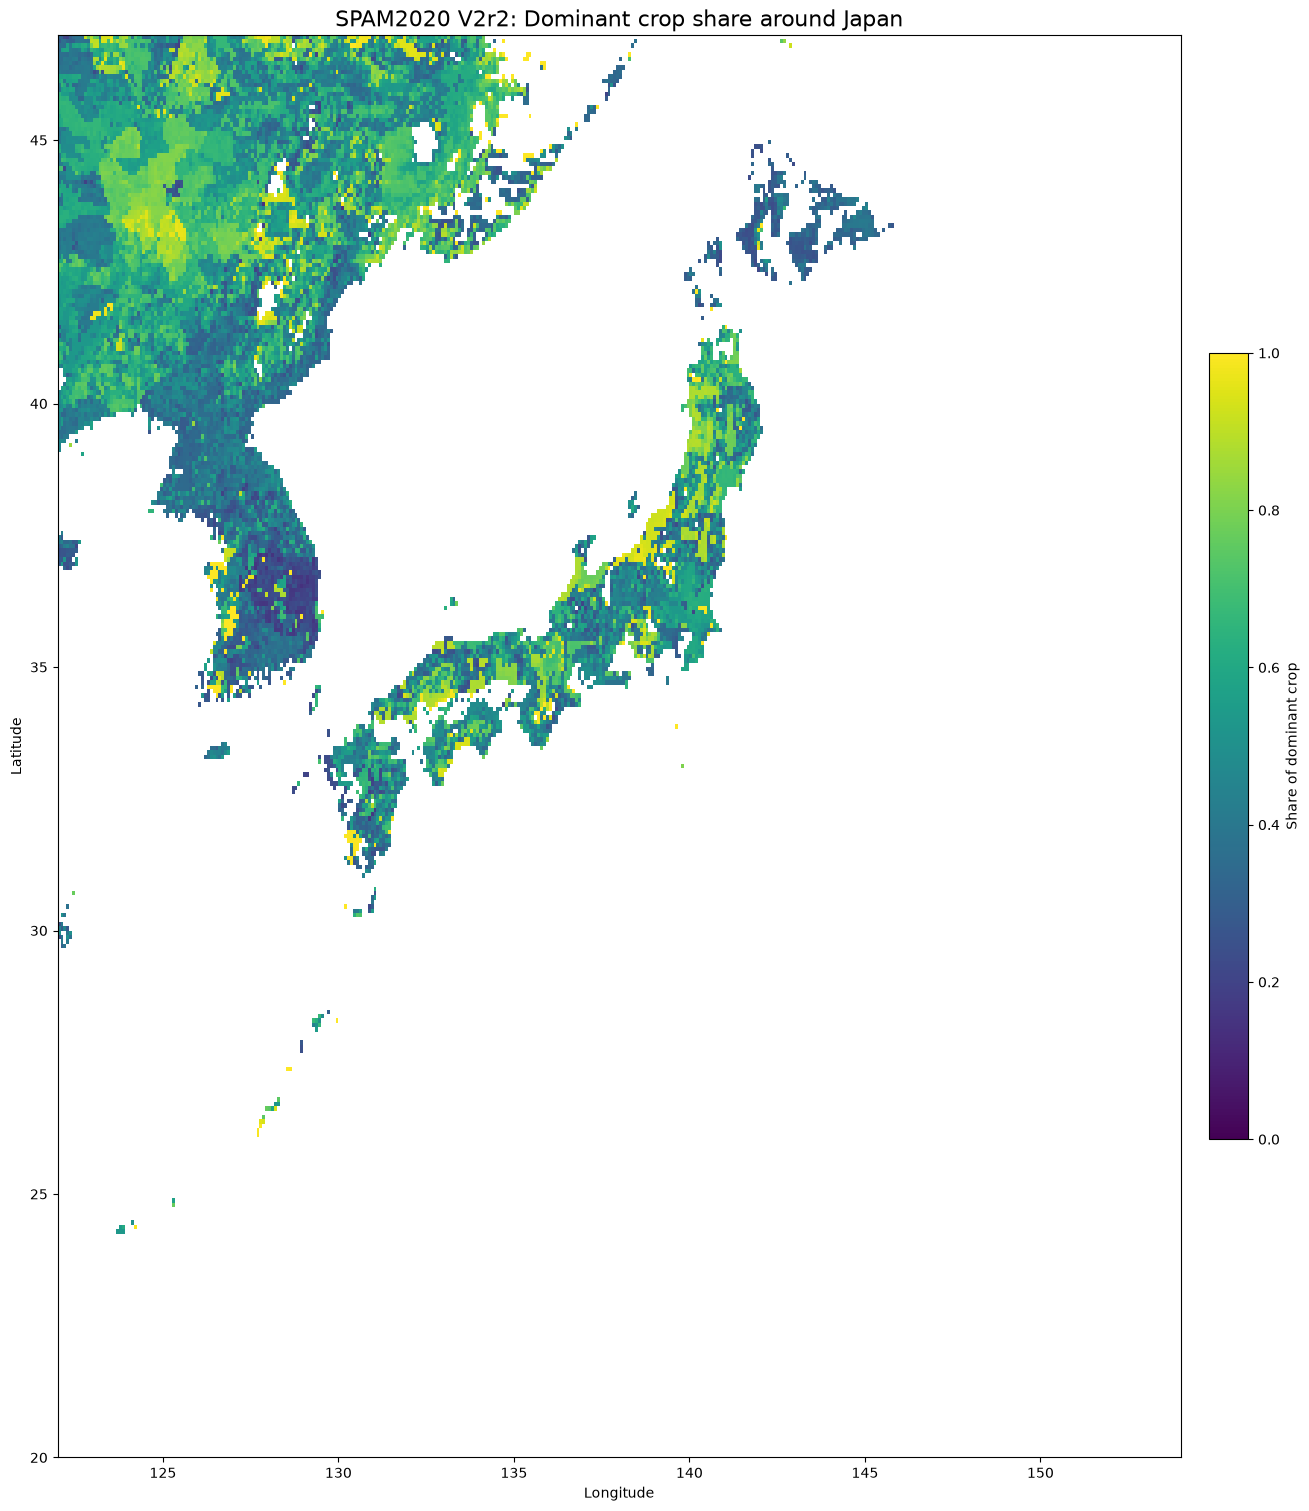

Saved: /work/tsuda/GAEZ/SPAM2020/visualization/spam2020_dominant_crop_share_japan_english.png


In [10]:
# ============================================================
# Dominant crop maps with full English crop names
# ============================================================

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap

# Use an English font only
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# Load saved arrays if necessary
if "OUTPUT_DIR" not in globals():
    OUTPUT_DIR = Path("/work/tsuda/GAEZ/SPAM2020/visualization")

if "crop_codes" not in globals():
    crop_codes = np.load(
        OUTPUT_DIR / "spam2020_crop_codes.npy",
        allow_pickle=True
    ).astype(str).tolist()

if "dominant_index" not in globals():
    dominant_index = np.load(
        OUTPUT_DIR / "spam2020_dominant_crop_index.npy"
    )

if "dominant_share" not in globals():
    dominant_share = np.load(
        OUTPUT_DIR / "spam2020_dominant_crop_share.npy"
    )

n_crops = len(crop_codes)

# Full English crop names
CROP_NAMES_EN = {
    "WHEA": "Wheat",
    "RICE": "Rice",
    "MAIZ": "Maize",
    "BARL": "Barley",
    "MILL": "Small millet",
    "PMIL": "Pearl millet",
    "SORG": "Sorghum",
    "OCER": "Other cereals",
    "POTA": "Potato",
    "SWPO": "Sweet potato",
    "YAMS": "Yams",
    "CASS": "Cassava",
    "ORTS": "Other roots",
    "BEAN": "Bean",
    "CHIC": "Chickpea",
    "COWP": "Cowpea",
    "PIGE": "Pigeon pea",
    "LENT": "Lentil",
    "OPUL": "Other pulses",
    "SOYB": "Soybean",
    "GROU": "Groundnut",
    "CNUT": "Coconut",
    "OILP": "Oil palm",
    "SUNF": "Sunflower",
    "RAPE": "Rapeseed",
    "SESA": "Sesame",
    "OOIL": "Other oil crops",
    "SUGC": "Sugarcane",
    "SUGB": "Sugar beet",
    "COTT": "Cotton",
    "OFIB": "Other fibre crops",
    "COFF": "Arabica coffee",
    "RCOF": "Robusta coffee",
    "COCO": "Cocoa",
    "TEAS": "Tea",
    "TOBA": "Tobacco",
    "BANA": "Banana",
    "PLNT": "Plantain",
    "CITR": "Citrus",
    "TROF": "Other tropical fruit",
    "TEMF": "Temperate fruit",
    "TOMA": "Tomato",
    "ONIO": "Onion",
    "VEGE": "Other vegetables",
    "RUBB": "Rubber",
    "REST": "Rest of crops",
}

crop_labels = [
    CROP_NAMES_EN.get(code, code)
    for code in crop_codes
]

# Mask cells with no crop area
dominant_for_plot = np.ma.masked_where(
    dominant_index < 0,
    dominant_index
)

# Stable categorical colors
colors = plt.cm.nipy_spectral(
    np.linspace(0.05, 0.95, n_crops)
)

dominant_cmap = ListedColormap(colors)

dominant_norm = BoundaryNorm(
    np.arange(-0.5, n_crops + 0.5, 1),
    n_crops
)

# Get map bounds from an existing variable
if "reference_bounds" not in globals():
    import rasterio

    spam_root = Path("/work/tsuda/GAEZ/SPAM2020")
    reference_tif = sorted(
        spam_root.rglob("*_A_*_A.tif")
    )[0]

    with rasterio.open(reference_tif) as src:
        reference_bounds = src.bounds


def draw_dominant_crop_map(
    title,
    output_path,
    xlim=None,
    ylim=None,
    figsize=(18, 13),
):
    fig, ax = plt.subplots(
        figsize=figsize,
        constrained_layout=True,
    )

    image = ax.imshow(
        dominant_for_plot,
        cmap=dominant_cmap,
        norm=dominant_norm,
        extent=(
            reference_bounds.left,
            reference_bounds.right,
            reference_bounds.bottom,
            reference_bounds.top,
        ),
        interpolation="nearest",
        aspect="auto",
    )

    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    if xlim is not None:
        ax.set_xlim(*xlim)

    if ylim is not None:
        ax.set_ylim(*ylim)

    # Vertical legend on the right
    colorbar = fig.colorbar(
        image,
        ax=ax,
        orientation="vertical",
        fraction=0.035,
        pad=0.025,
        ticks=np.arange(n_crops),
    )

    colorbar.ax.set_yticklabels(
        crop_labels,
        fontsize=8,
    )
    colorbar.set_label(
        "Dominant crop",
        fontsize=11,
    )

    fig.savefig(
        output_path,
        dpi=220,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    print("Saved:", output_path)


# ------------------------------------------------------------
# Global map
# ------------------------------------------------------------
draw_dominant_crop_map(
    title="SPAM2020 V2r2: Dominant crop by grid cell",
    output_path=(
        OUTPUT_DIR
        / "spam2020_dominant_crop_map_english_legend.png"
    ),
    figsize=(18, 13),
)

# ------------------------------------------------------------
# Japan-focused map
# ------------------------------------------------------------
draw_dominant_crop_map(
    title="SPAM2020 V2r2: Dominant crop around Japan",
    output_path=(
        OUTPUT_DIR
        / "spam2020_dominant_crop_map_japan_english.png"
    ),
    xlim=(122, 154),
    ylim=(20, 47),
    figsize=(13, 15),
)

# ------------------------------------------------------------
# Dominant-crop-share map around Japan
# ------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(13, 15),
    constrained_layout=True,
)

dominant_share_for_plot = np.ma.masked_where(
    dominant_index < 0,
    dominant_share,
)

image = ax.imshow(
    dominant_share_for_plot,
    cmap="viridis",
    vmin=0,
    vmax=1,
    extent=(
        reference_bounds.left,
        reference_bounds.right,
        reference_bounds.bottom,
        reference_bounds.top,
    ),
    interpolation="nearest",
    aspect="auto",
)

ax.set_xlim(122, 154)
ax.set_ylim(20, 47)

ax.set_title(
    "SPAM2020 V2r2: Dominant crop share around Japan",
    fontsize=16,
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

fig.colorbar(
    image,
    ax=ax,
    orientation="vertical",
    fraction=0.035,
    pad=0.025,
    label="Share of dominant crop",
)

japan_share_path = (
    OUTPUT_DIR
    / "spam2020_dominant_crop_share_japan_english.png"
)

fig.savefig(
    japan_share_path,
    dpi=220,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print("Saved:", japan_share_path)